# Changing descriptions with visual residual steering

**Input:** two COCO2014 images from the author POPE records, with the prompt “Please help me describe the image in detail.” **Model:** LLaVA-1.5-7B. **Tool:** VSV-style residual steering (part of VISTA); SLA is not included.

**Run mode:** the default cells replay real completed model measurements from `snapshots/`, using the public library visualization API. Saved outputs are retained. Set `RERUN = True` only after installing the model dependencies and configuring the optional run below. These examples are demonstrations, not dataset-level reproductions.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (parent / "demos" / "common.py").is_file() and (parent / "pyproject.toml").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display
from vlm_probing import Prober
from vlm_probing.visualization import (plot_input, plot_lens_heatmap, plot_attention_comparison,
                                       plot_causal_heatmap, plot_intervention_curves)
from demos.common import ASSETS, load_snapshot, load_image, show_figure, gqa_input, target_ranks
RERUN = False  # Keep False for the bundled, genuinely measured offline results.
print("Offline replay of archived model measurements; no inference or training.")

Offline replay of archived model measurements; no inference or training.


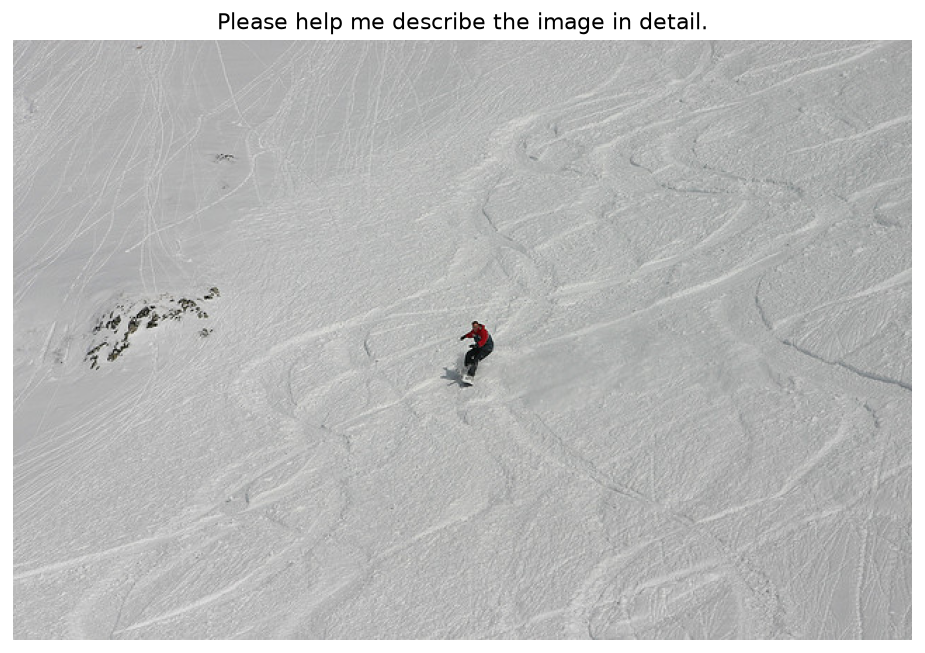

**Baseline**

The image captures a snowboarder skillfully riding down a snow-covered slope. The snowboarder is wearing a red jacket and is positioned in the center of the scene. The snowboard is visible beneath the snowboarder, as they glide down the hill.

The slope is covered with a layer of snow, and the snowboarder appears to be enjoying their time on the mountain. The scene is a perfect representation of winter sports and the excitement of snowboarding.

**VSV: strength 0.02**

The image captures a snowboarder skillfully riding down a snow-covered slope. The snowboarder is wearing a red jacket and is positioned in the middle of the scene. The snowboard is visible beneath the snowboarder, gliding smoothly down the slope. The snowy terrain is dotted with various tracks, indicating the popularity of the skiing and snowboarding area. The scene showcases the excitement and thrill of winter sports.

**VSV: strength 0.17**

The snow on the snow-covered snow ski snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow snow

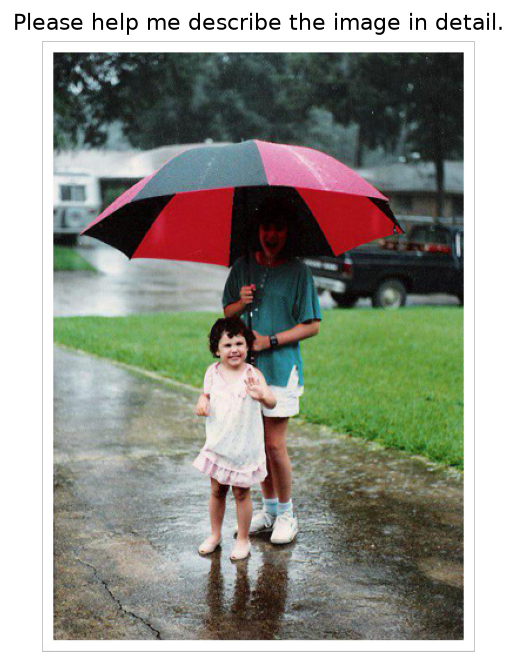

**Baseline**

The image features a woman and a young girl standing on a sidewalk in the rain. The woman is holding a red and black umbrella to protect them from the rain. The little girl is also holding an umbrella, which is slightly different from the woman's. They are both wearing shoes, and the woman is wearing a blue shirt.

In the background, there is a car parked on the street, and another car can be seen further away. The scene captures the moment when the woman and the little girl are walking together in the rain.

**VSV: strength 0.02**

The image features a woman and a young girl standing on a sidewalk in the rain. The woman is holding a red and black umbrella to protect them from the rain. The little girl is standing close to the woman, and they both appear to be enjoying the moment despite the wet weather.

In the background, there is a car parked on the street, and a truck can be seen further away. The scene captures the bond between the woman and the little girl as they share a rainy day together.

**VSV: strength 0.17**

In the rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain ina rain in a rain in a rain in a rain in a rain in a rain in a rain in a rain

In [2]:
records = [load_snapshot(f"steering_vsv/{sample}.json") for sample in ("310196","210789")]
for record in records:
    ax = plot_input(load_image(record["image_file"]), prompt=record["question"])
    show_figure(ax.figure)
    for label,key in [("Baseline","baseline"),("VSV: strength 0.02","vsv_weak"),("VSV: strength 0.17","vsv")]:
        display(Markdown(f"**{label}**\n\n"+record["generated"][key]["text"]))

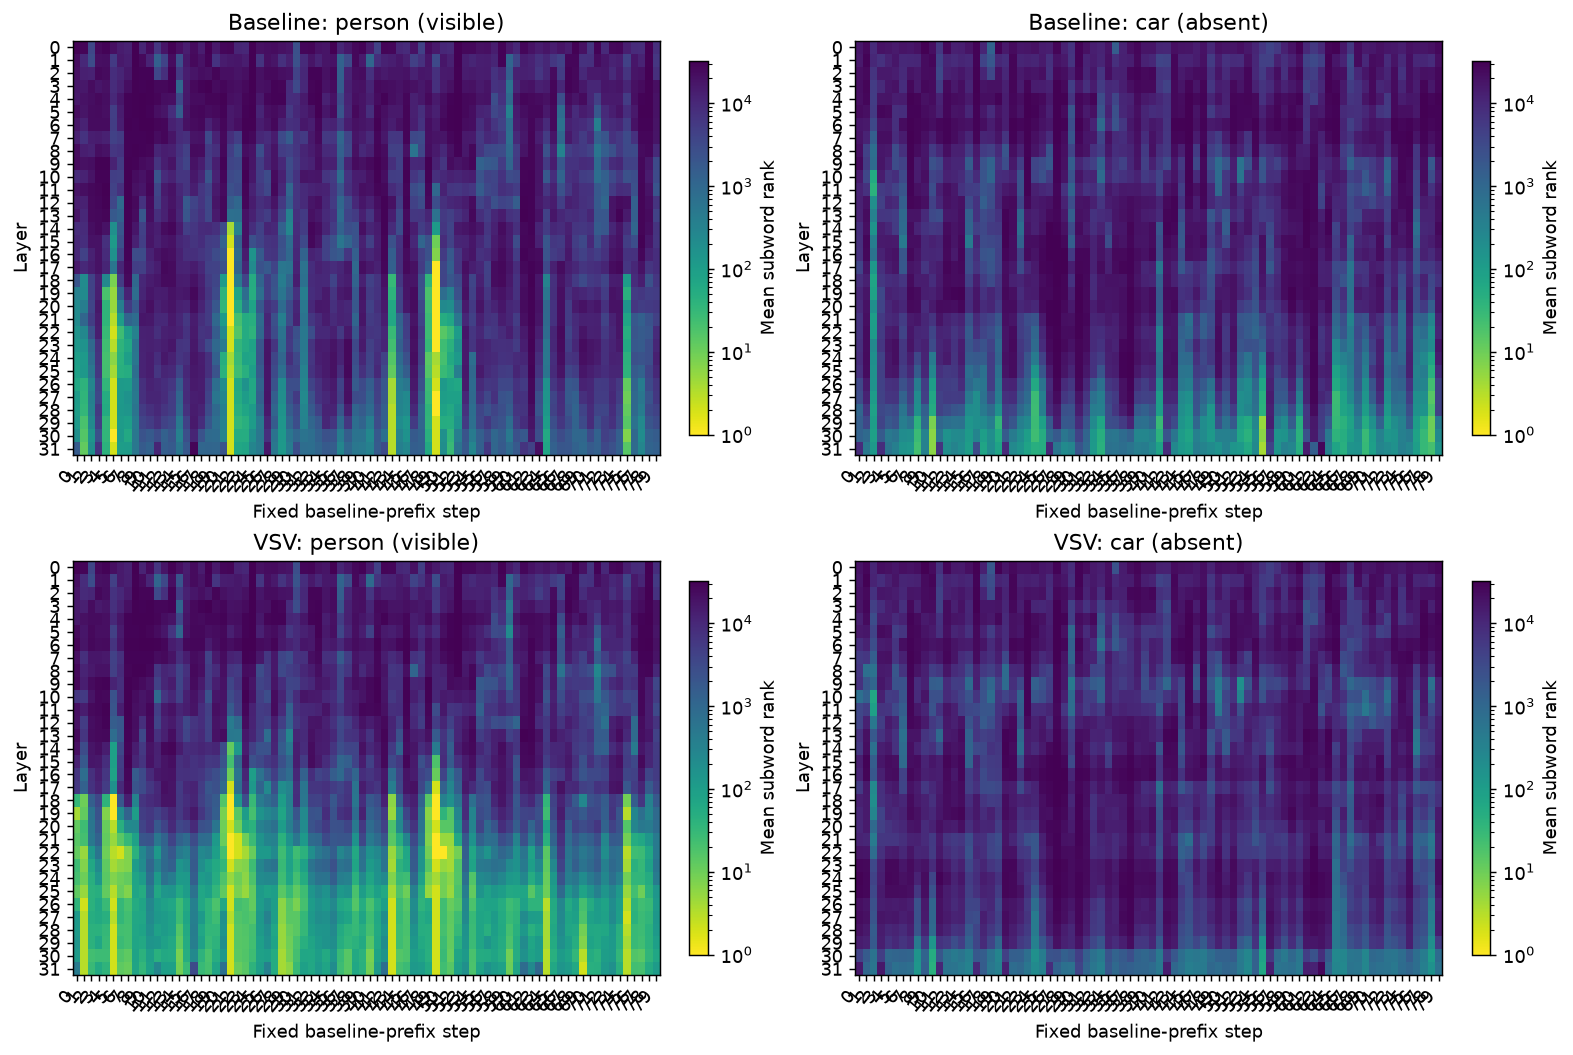

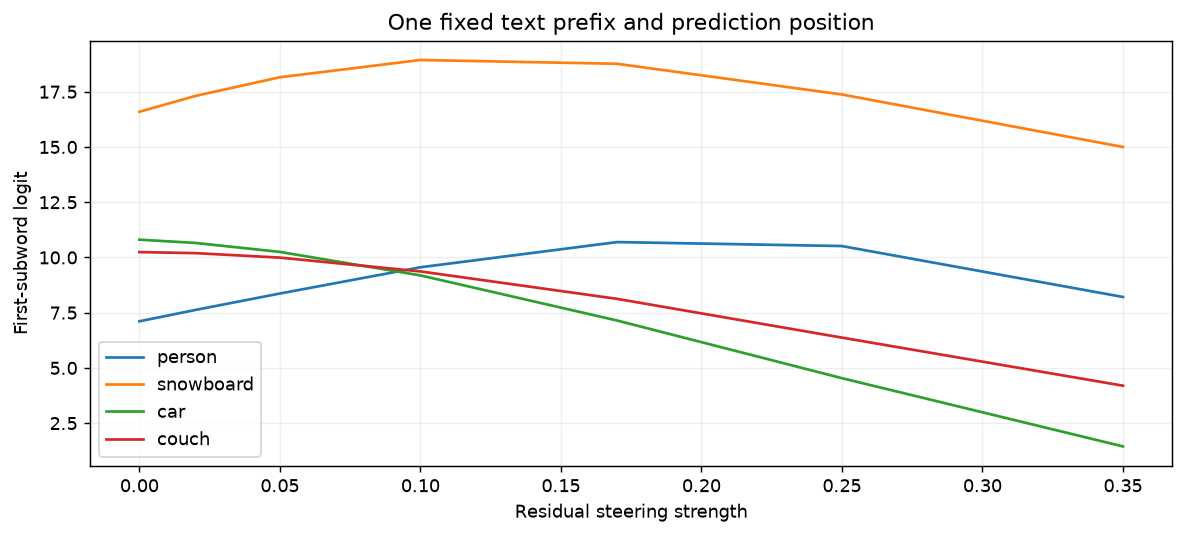

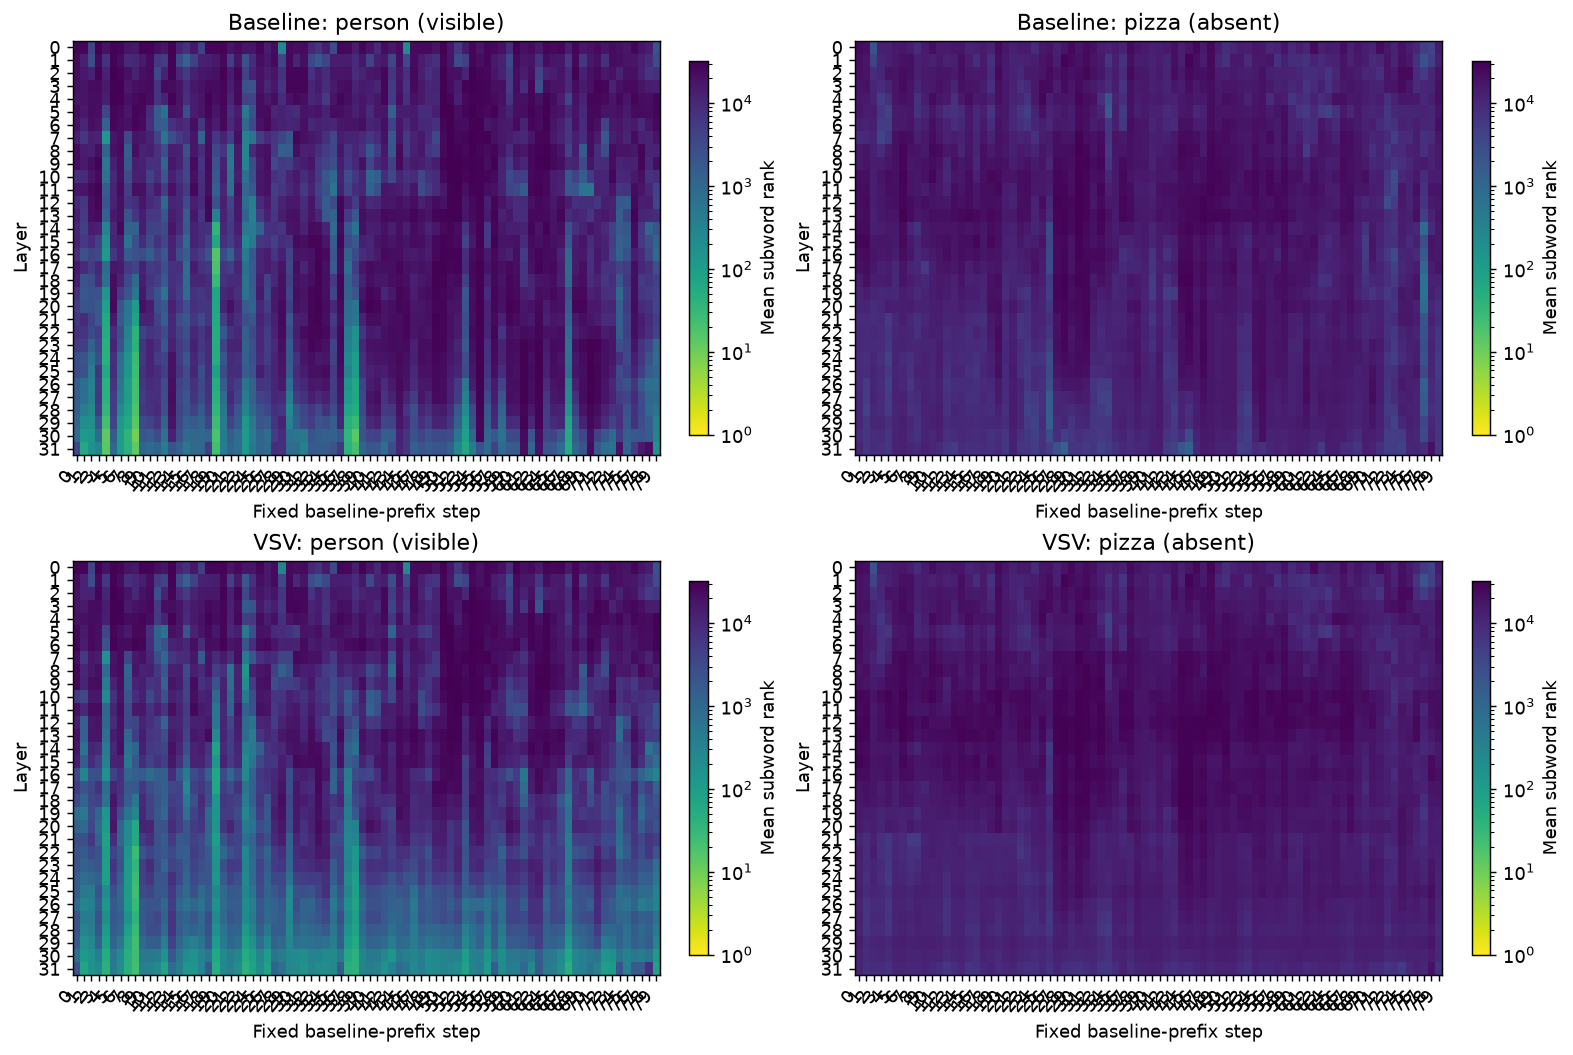

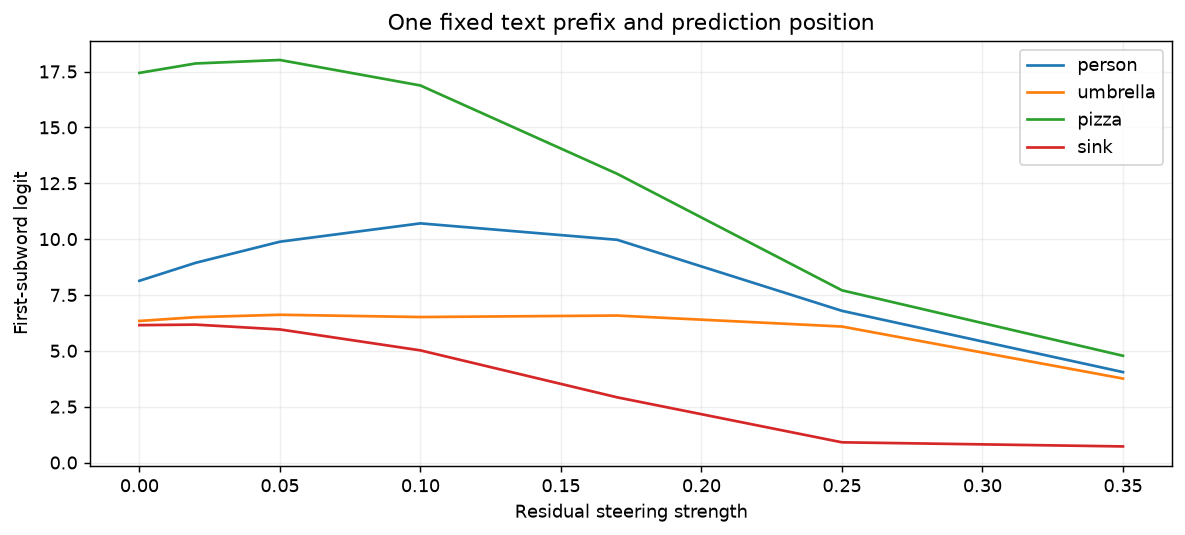

In [3]:
for record in records:
    # Exactly the same baseline-generated text prefixes are reused in both conditions.
    fig, axes = plt.subplots(2, 2, figsize=(12,8), constrained_layout=True)
    for row,(name,state) in enumerate([("Baseline",0),("VSV",1)]):
        visible = next(word for word,label in record["target_labels"].items() if label == "visible")
        absent = next(word for word,label in record["target_labels"].items() if label == "absent")
        for col,word in enumerate([visible,absent]):
            word_index = list(record["word_ids"]).index(word)
            ranks = np.asarray(record["ranks"])[state,word_index]
            plot_lens_heatmap(ranks, ax=axes[row,col], layer_labels=record["layers"],
                             title=f"{name}: {word} ({record['target_labels'][word]})",
                             value_label="Mean subword rank", vmin=1, vmax=record["vocab_size"])
            axes[row,col].set_xlabel("Fixed baseline-prefix step")
    show_figure(fig)
    response = record["strength_response"]
    ax = plot_intervention_curves({word:{"x":response["strengths"],"y":scores}
                                  for word,scores in response["scores"].items()},
                                  xlabel="Residual steering strength", ylabel="First-subword logit",
                                  title="One fixed text prefix and prediction position")
    show_figure(ax.figure)

**Scope and outcome:** the vectors are the positive image-context residual minus the negative text-only residual at each layer. Injection is additive and preserves the original residual norm at prediction positions. Stronger steering can produce repetitive decoding, which is preserved in the saved output. This demo follows the paper equations; the released author code additionally uses PCA/cosine-dependent MLP edits. It is a VSV transfer, not full VISTA. Rank panels average multiple subword ranks; they are not whole-word probabilities. Text outputs are actual generations, not rewritten captions.

## Optional new model run

This cell is deliberately opt-in. `VLM_PROBING_MODEL` selects a Hugging Face model ID or local checkpoint; `VLM_PROBING_DEVICE` selects the device. Hugging Face uses its normal cache (`HF_HOME` can relocate it). Rerunning performs fresh forwards and may need a GPU. An architecture-specific input adapter may be needed when changing the model; inspect `probe.describe()` first.

In [4]:
if RERUN:
    from demos.runtime import bind_model, prepared_chat
    probe, processor, device = bind_model("llava-hf/llava-1.5-7b-hf", attention=False)
    image = load_image(records[0]["image_file"])
    positive = prepared_chat(probe, processor, records[0]["question"], image)
    negative = prepared_chat(probe, processor, records[0]["question"])
    vectors = probe.causal.vsv(positive, negative)
    for strength in (0., .02, .05):
        method = vectors.configure(strength=strength, tokens="prediction")
        result = method.generate(positive, direction=vectors.directions, max_new_tokens=100)
        print(f"Strength {strength}: {result.metadata['decoded_text'][0]}")
else:
    print("Fresh direction construction and generation skipped.")

Fresh direction construction and generation skipped.


## Sources and interpretation

**Paper:** [The Hidden Life of Tokens](https://arxiv.org/abs/2502.03628), VSV Sections 2.3, Figure 2; parameter study Figure 6; qualitative Figures 15–18. **Author repository:** [VISTA](https://github.com/LzVv123456/VISTA). **Data:** [COCO2014](https://cocodataset.org/), images 310196 and 210789 from `pope_coco/coco_pope_random.json`; not claimed identical to paper Figure 15. Image-specific hashes and URLs are in `assets/coco_samples.json`.

Bundled image and data attribution is listed in [README.md](README.md) and [image notices](assets/images/SOURCE_NOTICES.md). Model checkpoints and fitted lens artifacts are not included.